# Two-point diffusion: from forward sampling to reverse generation

A minimal DDPM-style diffusion model where $X \in \{-1, +1\}$ with prior $P(X=-1) = a$. Same algorithm as Ho et al. 2020 — just with a tiny MLP instead of a U-Net and a two-point prior instead of images.

Covers parts 2–6 of the assignment:
- Part 2: forward sampling with a $\beta$ schedule
- Part 3: train an MLP to predict $x_0$ from $(x_t, t)$
- Part 4: validate the network against the analytical $\tanh$ reverse
- Part 5: train two networks at different $a$ to show prior is learned
- Part 6: reverse sampling to generate fresh $x_0$ samples


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


## Schedule

Define $\beta_t = \beta_0 + t\delta$ for $t = 1, \ldots, T$. Precompute $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{s=1}^t \alpha_s$.

**Indexing convention:** All schedule arrays have length $T+1$, with index 0 reserved for "no noise" ($\beta_0 = 0$, $\alpha_0 = 1$, $\bar\alpha_0 = 1$). This makes the formula $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,z$ work cleanly for any $t \in [0, T]$.


In [2]:
T = 25
beta_0_param = 0.01
delta = 0.01

beta = torch.zeros(T + 1)
beta[1:] = torch.tensor([beta_0_param + t * delta for t in range(1, T + 1)])

alpha = 1.0 - beta                 # alpha[0] = 1.0
alpha_bar = torch.cumprod(alpha, 0)  # alpha_bar[0] = 1.0

print(f"beta_T = {beta[T]:.4f}")
print(f"alpha_bar_T = {alpha_bar[T]:.4f}")
print(f"signal scale at T:  sqrt(alpha_bar_T) = {torch.sqrt(alpha_bar[T]):.4f}")
print(f"noise std at T:     sqrt(1 - alpha_bar_T) = {torch.sqrt(1 - alpha_bar[T]):.4f}")


beta_T = 0.2600
alpha_bar_T = 0.0211
signal scale at T:  sqrt(alpha_bar_T) = 0.1452
noise std at T:     sqrt(1 - alpha_bar_T) = 0.9894


## Part 2 — Forward sampler

The closed-form jump:
$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1 - \bar\alpha_t}\,z, \qquad z \sim \mathcal{N}(0, 1)$$

Each training sample is generated independently — sample $x_0$ from the prior, sample $t$ uniformly, sample $z$, compute $x_t$. No need to iterate the chain.


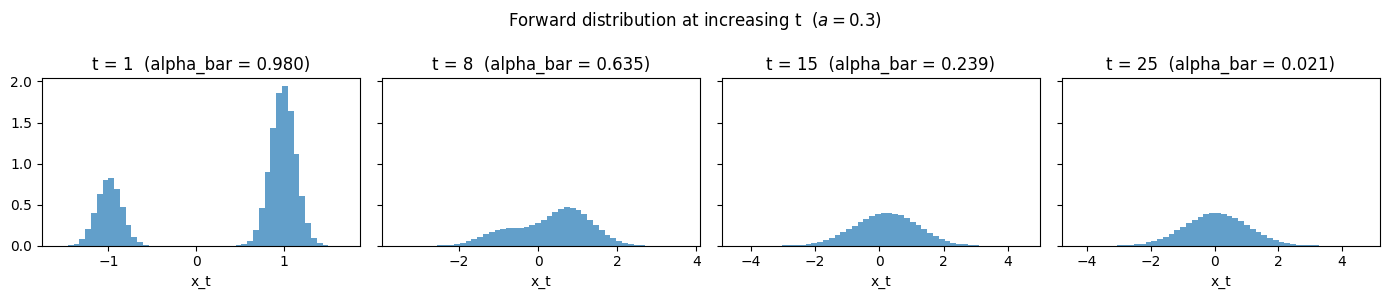

In [28]:
def sample_batch(batch_size, a):
    """Sample (x_0, x_t, t) triples using the one-shot forward formula."""
    x_0 = torch.where(torch.rand(batch_size) < a, -1.0, 1.0)
    t = torch.randint(1, T + 1, (batch_size,))   # t in {1, ..., T}
    z = torch.randn(batch_size)
    abar = alpha_bar[t]
    x_t = torch.sqrt(abar) * x_0 + torch.sqrt(1 - abar) * z
    return x_0, x_t, t

# Visualize the forward distribution at several t
a_demo = 0.3
N = 1000000
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, t_val in zip(axes, [1, 8, 15, 25]):
    x_0 = torch.where(torch.rand(N) < a_demo, -1.0, 1.0)
    z = torch.randn(N)
    abar = alpha_bar[t_val]
    x_t = torch.sqrt(abar) * x_0 + torch.sqrt(1 - abar) * z
    ax.hist(x_t.numpy(), bins=50, density=True, alpha=0.7)
    ax.set_title(f"t = {t_val}  (alpha_bar = {abar:.3f})")
    ax.set_xlabel('x_t')
plt.suptitle(f"Forward distribution at increasing t  ($a = {a_demo}$)")
plt.tight_layout()
plt.show()


## Part 3 — Tiny MLP and training loop

Input: $(x_t, t/T)$. Output: predicted $\hat x_0$. Two hidden layers, ReLU, no output activation (the MSE loss will pull predictions toward $\pm 1$ naturally; adding a `tanh` head saturates and slows training).

This is DDPM Algorithm 1 verbatim — sample a random triple per gradient step, MSE on the $x_0$ target.


Training with a = 0.5 ...
  iter     0: loss = 0.8946
  iter  1000: loss = 0.5263
  iter  2000: loss = 0.6443
  iter  3000: loss = 0.5821
  iter  4000: loss = 0.5568
  iter  4999: loss = 0.5123


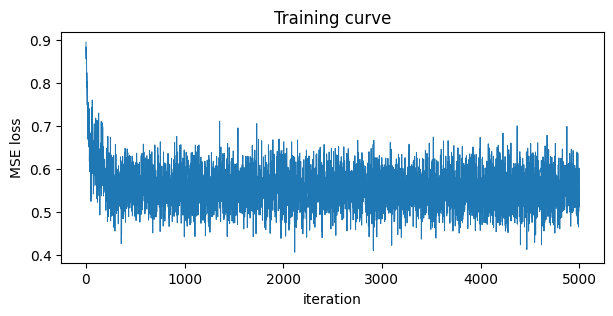

In [16]:
class DenoiserMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x_t, t):
        t_norm = t.float() / T   # normalize t to [0, 1]
        inp = torch.stack([x_t, t_norm], dim=-1)
        return self.net(inp).squeeze(-1)


def train(a, n_iters=5000, batch_size=256, lr=1e-3, verbose=True):
    model = DenoiserMLP()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for i in range(n_iters):
        x_0, x_t, t = sample_batch(batch_size, a)
        x_0_pred = model(x_t, t)
        loss = ((x_0_pred - x_0) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if verbose and (i % 1000 == 0 or i == n_iters - 1):
            print(f'  iter {i:>5d}: loss = {loss.item():.4f}')
    return model, losses

print('Training with a = 0.5 ...')
model, losses = train(a=0.5)

plt.figure(figsize=(7, 3))
plt.plot(losses, lw=0.7)
plt.xlabel('iteration')
plt.ylabel('MSE loss')
plt.title('Training curve')
plt.show()


## Part 4 — Compare network to analytical reverse

The closed-form benchmark:
$$\mathbb{E}[X \mid X_t = y] = \tanh\!\left(\frac{y\sqrt{\bar\alpha_t}}{1-\bar\alpha_t} - \tfrac{1}{2}\log\tfrac{a}{1-a}\right)$$

Plot the network's prediction and the analytical curve on the same axes for several $t$. They should overlap. **The network was never told $a$ — it learned the prior from samples.**


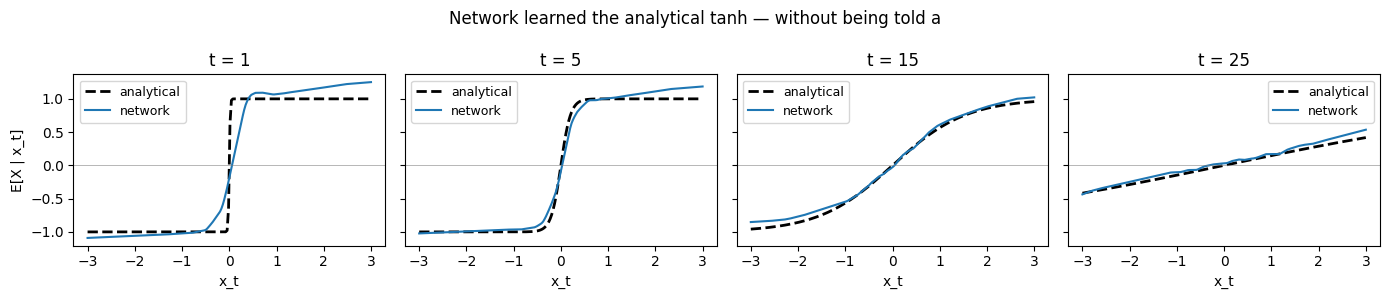

In [17]:
def closed_form_reverse(y, t_val, a):
    abar = float(alpha_bar[t_val])
    snr = np.sqrt(abar) / (1.0 - abar)
    bias = 0.5 * np.log(a / (1.0 - a))
    return np.tanh(y * snr - bias)

y_grid = torch.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, t_val in zip(axes, [1, 5, 15, 25]):
    with torch.no_grad():
        t_batch = torch.full((len(y_grid),), t_val)
        pred = model(y_grid, t_batch).numpy()
    truth = closed_form_reverse(y_grid.numpy(), t_val, a=0.5)
    ax.plot(y_grid.numpy(), truth, 'k--', lw=2, label='analytical')
    ax.plot(y_grid.numpy(), pred,  'C0', lw=1.5, label='network')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x_t')
    ax.axhline(0, color='gray', lw=0.4)
    ax.legend(fontsize=9)
axes[0].set_ylabel('E[X | x_t]')
plt.suptitle('Network learned the analytical tanh — without being told a')
plt.tight_layout()
plt.show()


## Part 5 — Prior is implicit in the weights

Train two networks on data with different $a$. The prediction functions will be shifted versions of each other — same shape, different bias. The network's weights have absorbed the prior.


Training a = 0.3 ...
Training a = 0.7 ...
done.


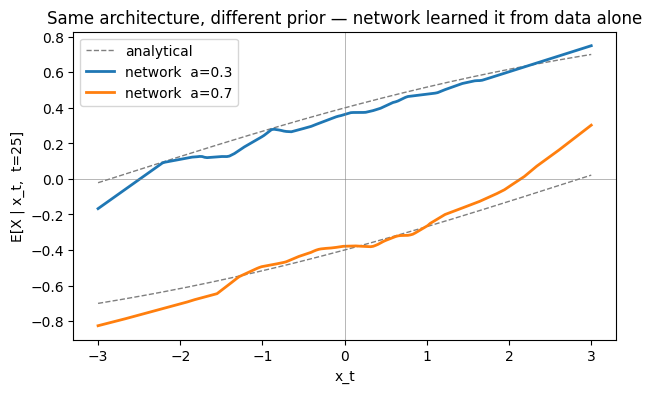

In [29]:
print('Training a = 0.3 ...')
model_03, _ = train(a=0.3, verbose=False)
print('Training a = 0.7 ...')
model_07, _ = train(a=0.7, verbose=False)
print('done.')

y_grid = torch.linspace(-3, 3, 200)
t_val = 25
t_batch = torch.full((len(y_grid),), t_val)

with torch.no_grad():
    pred_03 = model_03(y_grid, t_batch).numpy()
    pred_07 = model_07(y_grid, t_batch).numpy()
truth_03 = closed_form_reverse(y_grid.numpy(), t_val, a=0.3)
truth_07 = closed_form_reverse(y_grid.numpy(), t_val, a=0.7)

plt.figure(figsize=(7, 4))
plt.plot(y_grid.numpy(), truth_03, 'k--', lw=1, alpha=0.5, label='_')
plt.plot(y_grid.numpy(), truth_07, 'k--', lw=1, alpha=0.5, label='analytical')
plt.plot(y_grid.numpy(), pred_03, lw=2, label='network  a=0.3')
plt.plot(y_grid.numpy(), pred_07, lw=2, label='network  a=0.7')
plt.axhline(0, color='gray', lw=0.4)
plt.axvline(0, color='gray', lw=0.4)
plt.xlabel('x_t')
plt.ylabel(f'E[X | x_t,  t={t_val}]')
plt.title('Same architecture, different prior — network learned it from data alone')
plt.legend()
plt.show()


## Part 6 — Reverse sampling

DDPM Algorithm 2, using the $x_0$ prediction parameterization. At each step compute the posterior mean
$$\tilde\mu_t = \frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}\,\hat x_0 + \frac{\sqrt{\alpha_t}(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\,x_t$$
and posterior variance $\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$.  Sample $x_{t-1} \sim \mathcal{N}(\tilde\mu_t, \tilde\beta_t)$ for $t > 1$, and just take the mean at $t = 1$ (standard DDPM trick).


P(X = -1) empirical from reverse sampling: 0.503
P(X = -1) target (a):                       0.500

From a=0.7 model:
P(X = -1) empirical: 0.717
P(X = -1) target:    0.700


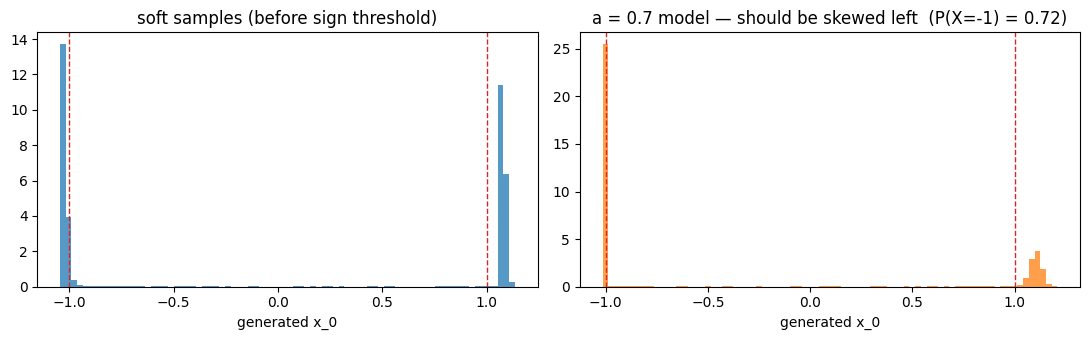

In [19]:
def reverse_sample(model, n_samples=20000):
    """Run the reverse chain from x_T ~ N(0,1) back to x_0."""
    x = torch.randn(n_samples)
    with torch.no_grad():
        for t in range(T, 0, -1):
            t_batch = torch.full((n_samples,), t)
            x0_hat = model(x, t_batch)

            abar_t   = alpha_bar[t]
            abar_tm1 = alpha_bar[t - 1]
            beta_t   = beta[t]
            alpha_t  = alpha[t]

            mu = (torch.sqrt(abar_tm1) * beta_t / (1 - abar_t)) * x0_hat \
               + (torch.sqrt(alpha_t)  * (1 - abar_tm1) / (1 - abar_t)) * x

            if t > 1:
                sigma = torch.sqrt((1 - abar_tm1) / (1 - abar_t) * beta_t)
                x = mu + sigma * torch.randn(n_samples)
            else:
                x = mu
    return x

# Generate from the a = 0.5 model
samples = reverse_sample(model, n_samples=20000)
p_neg = (torch.sign(samples) == -1).float().mean().item()
print(f'P(X = -1) empirical from reverse sampling: {p_neg:.3f}')
print(f'P(X = -1) target (a):                       0.500')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(samples.numpy(), bins=80, density=True, alpha=0.75)
axes[0].axvline(-1, color='C3', ls='--', lw=1)
axes[0].axvline( 1, color='C3', ls='--', lw=1)
axes[0].set_title('soft samples (before sign threshold)')
axes[0].set_xlabel('generated x_0')

# Compare against a different a
samples_07 = reverse_sample(model_07, n_samples=20000)
p_neg_07 = (torch.sign(samples_07) == -1).float().mean().item()
print(f'\nFrom a=0.7 model:')
print(f'P(X = -1) empirical: {p_neg_07:.3f}')
print(f'P(X = -1) target:    0.700')
axes[1].hist(samples_07.numpy(), bins=80, density=True, alpha=0.75, color='C1')
axes[1].axvline(-1, color='C3', ls='--', lw=1)
axes[1].axvline( 1, color='C3', ls='--', lw=1)
axes[1].set_title(f'a = 0.7 model — should be skewed left  (P(X=-1) = {p_neg_07:.2f})')
axes[1].set_xlabel('generated x_0')

plt.tight_layout()
plt.show()


## What you've just implemented

You've written DDPM end-to-end:
- A real $\beta$ schedule with the variance-preserving forward kernel
- The one-shot training formula $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,z$
- Algorithm 1 (training): sample triples, predict $x_0$, MSE loss
- Algorithm 2 (sampling): iterative reverse chain using the analytical posterior

**Now imagine $X$ is a $256 \times 256$ image.** Which lines of code would change?

Two: replace `DenoiserMLP` with a U-Net, and replace the prior sampler with reading a real image dataset. Everything else — the schedule, the forward formula, the training loop, the reverse sampler — is the same code you just wrote.
